# CKYC SFTP Log Investigation Analysis

**Candidate:** Manish Kumar          
**Role:** Data Analyst Assignment  
**Date:** 17 March 2026  

#### This analysis investigates SFTP connection logs to identify failure patterns, system issues, and customer impact.

### Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

In [3]:
df = pd.read_csv("ckyc.SFTPConnectionLog.anonymized.csv")

In [4]:
df.head()

,_id,email,credential_label,operation,success,error_message,error_type,elapsed_seconds,created_at
0,698dcb0d282a37f2cd044bc8,user003@example.com,default,bulk_download,False,Login timeout expired,ConnectionLost,31.041,2026-02-12T12:43:57.384Z
1,698dcb2b282a37f2cd044bca,user003@example.com,default,bulk_download,False,Login timeout expired,ConnectionLost,30.274,2026-02-12T12:44:27.782Z
2,698dcb4a282a37f2cd044bcc,user003@example.com,default,bulk_download,False,Login timeout expired,ConnectionLost,30.303,2026-02-12T12:44:58.183Z
3,698dcb68282a37f2cd044bce,user003@example.com,default,bulk_download,False,Login timeout expired,ConnectionLost,30.329,2026-02-12T12:45:28.623Z
4,698dcb86282a37f2cd044bd0,user003@example.com,default,bulk_download,False,Login timeout expired,ConnectionLost,30.266,2026-02-12T12:45:58.988Z


### The dataset is loaded into a Pandas DataFrame to begin the analysis.

### Data Understanding

In [5]:
df.shape

(68177, 9)

In [6]:
df.columns

Index(['_id', 'email', 'credential_label', 'operation', 'success',
       'error_message', 'error_type', 'elapsed_seconds', 'created_at'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68177 entries, 0 to 68176
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               68177 non-null  object 
 1   email             68177 non-null  object 
 2   credential_label  68177 non-null  object 
 3   operation         68177 non-null  object 
 4   success           68177 non-null  bool   
 5   error_message     42320 non-null  object 
 6   error_type        42320 non-null  object 
 7   elapsed_seconds   68177 non-null  float64
 8   created_at        68177 non-null  object 
dtypes: bool(1), float64(1), object(7)
memory usage: 4.2+ MB


#### The dataset contains SFTP request-level logs including customer identifiers (email), operation types, success status, error types, and timestamps (created_at).

In [8]:
df.describe(include='all')

,_id,email,credential_label,operation,success,error_message,error_type,elapsed_seconds,created_at
count,68177,68177,68177,68177,68177,42320,42320,68177.000000,68177
unique,68177,5,1,11,2,21,7,NaN,68142
top,69b3aca3054b8fa0fd591184,user003@example.com,default,bulk_download,False,Permission denied,PermissionDenied,NaN,2026-02-17T16:13:27.043Z
freq,1,48892,68177,54280,42320,26133,26153,NaN,2
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.597165,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.548068,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.064000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.414000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.344000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.210000,NaN


#### A statistical summary of the dataset shows that it contains 68k+ records with 5 unique customers. The most frequent operation is bulk_download, and multiple error types are present, indicating diverse failure scenarios.

### Data Cleaning

In [9]:
# Convert date
df['created_at'] = pd.to_datetime(df['created_at'])
df['date'] = df['created_at'].dt.date

In [10]:
# Create failure column
df['is_failure'] = df['success'] == False

In [11]:
df.sample(5)

,_id,email,credential_label,operation,success,error_message,error_type,elapsed_seconds,created_at,date,is_failure
4242,698eb1179bd4dc21226a2519,user003@example.com,default,download,True,NaN,NaN,4.252,2026-02-13 05:05:27.484000+00:00,2026-02-13,False
41079,69962659a83046e9581375db,user005@example.com,default,bulk_download,False,SSH connection to uploads.ckycindia.in:6010 ti...,TimeoutError,60.119,2026-02-18 20:51:37.103000+00:00,2026-02-18,True
47151,6997a4901425c6e046254679,user005@example.com,default,bulk_download,False,SSH connection to uploads.ckycindia.in:6010 ti...,TimeoutError,60.104,2026-02-20 00:02:24.625000+00:00,2026-02-20,True
53756,6998fd8d1232e3d9a4681635,user003@example.com,default,bulk_download,True,NaN,NaN,3.369,2026-02-21 00:34:21.372000+00:00,2026-02-21,False
15303,6991013fab1bdbe505037ca1,user003@example.com,default,bulk_download,False,Permission denied,PermissionDenied,8.782,2026-02-14 23:11:59.494000+00:00,2026-02-14,True


#### The dataset is cleaned by converting timestamps and creating a failure flag. A few sample rows are displayed to confirm that the date conversion and newly created columns have been applied correctly.

### Missing Values

In [12]:
df.isnull().sum()

_id                     0
email                   0
credential_label        0
operation               0
success                 0
error_message       25857
error_type          25857
elapsed_seconds         0
created_at              0
date                    0
is_failure              0
dtype: int64

#### The dataset is checked for missing values to ensure data quality.

In [13]:
df[df['success'] == True][['error_type','error_message']].head(10)

,error_type,error_message
254,NaN,NaN
255,NaN,NaN
256,NaN,NaN
313,NaN,NaN
314,NaN,NaN
319,NaN,NaN
320,NaN,NaN
321,NaN,NaN
322,NaN,NaN
325,NaN,NaN


#### Missing values in error_type and error_message occur only for successful requests, as no error information is generated when operations complete successfully.

### EDA

In [14]:
# Success vs Failure
df['success'].value_counts()

success
False    42320
True     25857
Name: count, dtype: int64

In [15]:
# Unique customers
df['email'].nunique()

5

In [16]:
# Operation Distribution
df['operation'].value_counts()

operation
bulk_download            54280
upload                    5576
download                  4985
bulk_download_session     2032
download_session           767
bulk_upload_session        431
probe                       77
list_responses              10
update_session               9
list_input                   7
upload_session               3
Name: count, dtype: int64

In [17]:
# Error distribution
df['error_type'].value_counts()


error_type
PermissionDenied     26153
TimeoutError          8667
ConnectionLost        7214
ChannelOpenError       271
FileNotFoundError       10
OSError                  3
SFTPNoSuchFile           2
Name: count, dtype: int64

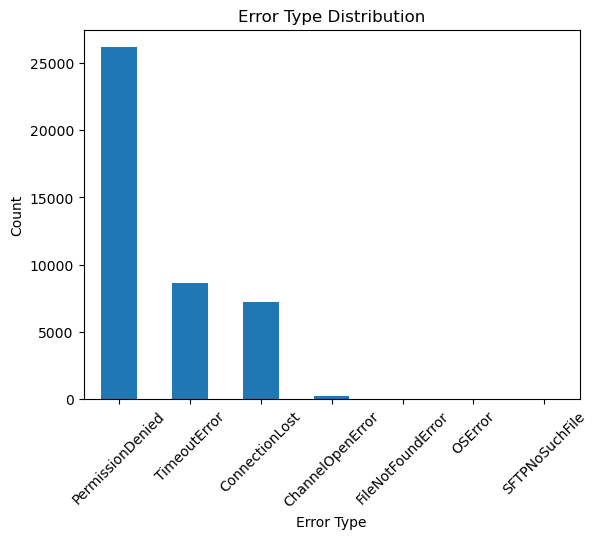

In [18]:
df['error_type'].value_counts().plot(kind='bar')
plt.title("Error Type Distribution")
plt.xlabel("Error Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### The chart shows that PermissionDenied is the most frequent error, followed by ConnectionLost and TimeoutError.

In [19]:
# Success vs Failure %
(df['success'].value_counts(normalize=True) * 100)

success
False    62.07372
True     37.92628
Name: proportion, dtype: float64

In [20]:
#Requests per Customer
df['email'].value_counts()

email
user003@example.com    48892
user005@example.com    18423
user001@example.com      738
user002@example.com      118
user004@example.com        6
Name: count, dtype: int64

In [21]:
# Execution Time Analysis
df['elapsed_seconds'].describe()

count    68177.000000
mean        17.597165
std         22.548068
min          0.064000
25%          4.414000
50%          7.344000
75%         30.210000
max        722.034000
Name: elapsed_seconds, dtype: float64

### TIME-BASED ANALYSIS

In [22]:
daily = df.groupby('date').agg(
    total=('success','count'),
    failures=('is_failure','sum')
)

daily['failure_rate'] = (daily['failures']/daily['total'])*100
daily.reset_index(inplace=True)

daily.head()

,date,total,failures,failure_rate
0,2026-02-12,2932,456,15.552524
1,2026-02-13,6371,2546,39.962329
2,2026-02-14,6198,6198,100.000000
3,2026-02-15,6201,6201,100.000000
4,2026-02-16,6523,6523,100.000000


#### Failure Trend

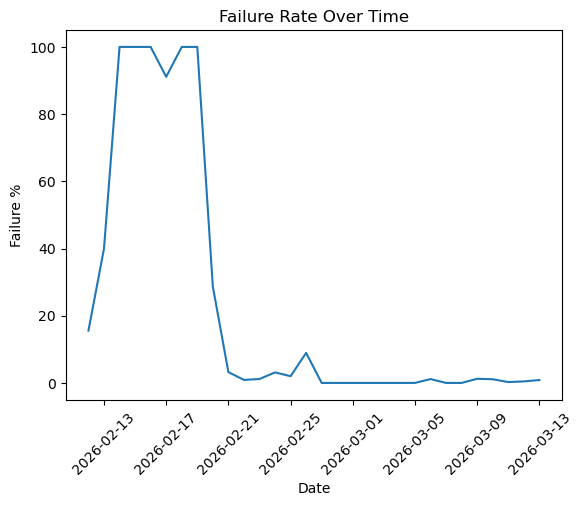

In [23]:
plt.plot(daily['date'], daily['failure_rate'])
plt.xticks(rotation=45)
plt.title("Failure Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Failure %")
plt.show()

#### The chart clearly shows a sharp spike in failure rate during mid-February, increasing from low levels to nearly 100%, indicating a system-wide outage.

### Q1. Main Failure Patterns

In [24]:
df[df['is_failure']].groupby('error_type').size().sort_values(ascending=False)

error_type
PermissionDenied     26153
TimeoutError          8667
ConnectionLost        7214
ChannelOpenError       271
FileNotFoundError       10
OSError                  3
SFTPNoSuchFile           2
dtype: int64

In [25]:
customer_pattern = df.groupby('email').agg(
    total=('success','count'),
    failures=('is_failure','sum')
)

customer_pattern['failure_rate'] = (customer_pattern['failures']/customer_pattern['total'])*100
customer_pattern.sort_values(by='failure_rate', ascending=False)

,total,failures,failure_rate
email,,,
user004@example.com,6,6,100.000000
user005@example.com,18423,16398,89.008305
user003@example.com,48892,25900,52.973902
user002@example.com,118,4,3.389831
user001@example.com,738,12,1.626016


In [26]:
df.groupby('operation').agg(
    total=('success','count'),
    failures=('is_failure','sum')
)

,total,failures
operation,,
bulk_download,54280,35310
bulk_download_session,2032,13
bulk_upload_session,431,3
download,4985,1834
download_session,767,4
list_input,7,0
list_responses,10,1
probe,77,47
update_session,9,0


#### PermissionDenied is the most frequent error, followed by TimeoutError and ConnectionLost. Some customers show significantly higher failure rates.

### Q2. Customer vs System Issue

In [27]:
customer_daily = df.groupby(['date','email']).agg(
    total=('success','count'),
    failures=('is_failure','sum')
)

customer_daily['failure_rate'] = (customer_daily['failures']/customer_daily['total'])*100
customer_daily.reset_index(inplace=True)

In [28]:
customer_daily

,date,email,total,failures,failure_rate
0,2026-02-12,user001@example.com,1,1,100.000000
1,2026-02-12,user003@example.com,2930,454,15.494881
2,2026-02-12,user005@example.com,1,1,100.000000
3,2026-02-13,user003@example.com,6369,2544,39.943476
4,2026-02-13,user004@example.com,1,1,100.000000
...,...,...,...,...,...
79,2026-03-12,user005@example.com,110,1,0.909091
80,2026-03-13,user001@example.com,28,1,3.571429
81,2026-03-13,user002@example.com,30,0,0.000000
82,2026-03-13,user003@example.com,35,0,0.000000


#### During the peak failure period (mid-February), all customers show high failure rates simultaneously, indicating a system-wide issue.

#### Outside this period, failure rates vary across customers, with users like user005 and user003 showing higher failure rates than others, indicating customer-specific issues.

#### This pattern shows that the incident was primarily system-wide, with additional customer-specific differences outside the incident window.

### Q3. Change Point

#### Ans. A major change point is observed around mid-February (around Feb 14), where failure rates increase sharply from normal levels to near-total failure.

#### This indicates a sudden shift from stable system behavior to a system-wide incident.

#### The confidence in this change point is high, as the spike is clearly visible and consistent across the data.

### Q4. BEFORE vs AFTER

In [29]:
change_date = '2026-02-14'

before = df[df['date'] < pd.to_datetime(change_date).date()]
after = df[df['date'] >= pd.to_datetime(change_date).date()]

def summary(data):
    total = len(data)
    failures = data['is_failure'].sum()
    rate = (failures/total)*100
    return total, failures, rate

summary(before), summary(after)

((9303, np.int64(3002), np.float64(32.269160485864774)),
 (58874, np.int64(39318), np.float64(66.78329992866121)))

### Request Volume

In [30]:
print("Before Volume:", len(before))
print("After Volume:", len(after))

Before Volume: 9303
After Volume: 58874


### Success Rate

In [31]:
def success_rate(data):
    return (data['success'].sum() / len(data)) * 100

print("Before Success Rate:", success_rate(before))
print("After Success Rate:", success_rate(after))

Before Success Rate: 67.73083951413523
After Success Rate: 33.21670007133879


### Operation Mix

In [32]:
print("Before Operation Mix:")
print(before['operation'].value_counts(normalize=True)*100)

print("\nAfter Operation Mix:")
print(after['operation'].value_counts(normalize=True)*100)

Before Operation Mix:
operation
bulk_download    90.508438
download          6.986993
upload            2.461572
probe             0.042997
Name: proportion, dtype: float64

After Operation Mix:
operation
bulk_download            77.895166
upload                    9.082108
download                  7.363182
bulk_download_session     3.451439
download_session          1.302782
bulk_upload_session       0.732072
probe                     0.123994
list_responses            0.016985
update_session            0.015287
list_input                0.011890
upload_session            0.005096
Name: proportion, dtype: float64


### Error Composition

In [33]:
print("Before Errors:")
print(before[before['is_failure']]['error_type'].value_counts(normalize=True)*100)

print("\nAfter Errors:")
print(after[after['is_failure']]['error_type'].value_counts(normalize=True)*100)

Before Errors:
error_type
PermissionDenied    75.216522
ConnectionLost      21.452365
ChannelOpenError     3.264490
TimeoutError         0.066622
Name: proportion, dtype: float64

After Errors:
error_type
PermissionDenied     60.773691
TimeoutError         22.038252
ConnectionLost       16.709904
ChannelOpenError      0.440002
FileNotFoundError     0.025434
OSError               0.007630
SFTPNoSuchFile        0.005087
Name: proportion, dtype: float64


#### Before the incident, failures were mostly due to PermissionDenied (~75%), indicating configuration issues.
#### After the incident, The share of PermissionDenied errors decreased to (~61%), while TimeoutError increased to approximately 22% and other errors increased, showing system instability.
#### This indicates that the issue evolved from a configuration problem to a broader system failure involving multiple error types.

## Q5. Root Cause

#### Ans. Failures are not caused only by permission issues. Before the incident, PermissionDenied dominates (~75%), indicating configuration problems.

#### After the change point, TimeoutError (~22%) and ConnectionLost increase, along with new errors like FileNotFoundError, showing system instability.

#### Additionally, request volume remains high, suggesting retry behavior. This indicates both system issues and operational patterns contributed to the failures.

### Q6. Client Behavior

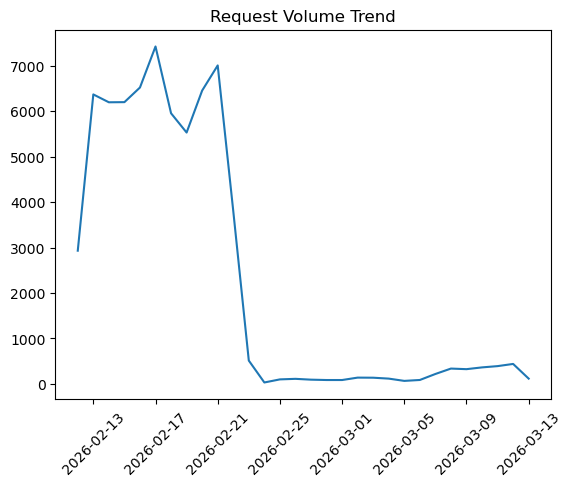

In [34]:
volume = df.groupby('date').size()

plt.plot(volume.index, volume.values)
plt.xticks(rotation=45)
plt.title("Request Volume Trend")
plt.show()

#### There is evidence that client interaction changed during the incident period. The request volume remains consistently high even when the failure rate increases significantly. This suggests that clients continued to send requests or retry failed operations instead of reducing traffic.
#### As a result, the sustained or increased request volume likely added additional load on the system, worsening the failure rates and contributing to system instability.

In [35]:
### Q7. IMPACTED CUSTOMERS

In [36]:
customer_pattern.sort_values(by='failure_rate', ascending=False)

,total,failures,failure_rate
email,,,
user004@example.com,6,6,100.000000
user005@example.com,18423,16398,89.008305
user003@example.com,48892,25900,52.973902
user002@example.com,118,4,3.389831
user001@example.com,738,12,1.626016


#### Customer impact is best measured using failure rate rather than raw counts.

#### Based on this, user005 89% and user003 (~53%) are the most impacted customers. Although user004 shows a 100% failure rate, its request volume is very low.

#### Users user001 and user002 show minimal impact with very low failure rates.

### Q8. Incident Narrative

#### The system was stable initially but experienced a sharp failure spike in mid-February.

#### Error patterns shifted from PermissionDenied to multiple errors, indicating system instability, likely worsened by client retries.

#### While the data suggests a system-wide outage, the exact root cause cannot be fully confirmed due to missing infrastructure data.

### Q9. Monitoring

#### Monitoring should track failure rate, error spikes, and request volume. Alerts should be triggered when failure rate exceeds a threshold or when specific errors spike.
#### Additionally, per-customer monitoring and anomaly detection can help detect issues early.

### Q10. Assumptions & Limitations

**Assumptions:**
- Each email represents a unique customer
- Success flag correctly indicates success or failure
- Logs are complete and reliable

**Additional Data Required:**
- Server performance data to check system load
- Network data to identify connectivity issues
- Retry data to understand client behavior
- Deployment logs to identify recent system changes

### Final Summary

#### The analysis identifies a clear system-wide outage during mid-February, where failure rates increased sharply from normal levels to near-total failure.

#### The issue evolved from configuration-related errors (PermissionDenied) to broader system instability, including TimeoutError and connection-related failures.

#### Additionally, sustained request volume suggests client retry behavior, which likely increased system load and worsened the incident.

#### The near-simultaneous failure across all customers strongly indicates a centralized system failure rather than isolated user issues.

## Action Plan

#### 1. Monitor failure rates and errors in real time to detect issues early.
#### 2. Set alerts when failure rate or specific errors increase.
#### 3. Track performance per customer to identify affected users.
#### 4. Limit retry attempts to prevent system overload.
#### 5. Monitor system performance (CPU, memory, network) to detect system issues.